# Unsupervised Learning & K-Means Clustering

## step 1- Load and scale a provided dataset


### Load the Dataset

In [4]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv"
)

df.head()

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,0,Never,2.9,86,5.4,19.8,1,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,0,Never,3.0,132,4.3,45.8,1,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,0,Current,3.5,128,5.1,17.7,1,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,0,Never,2.7,18,6.8,63.6,1,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,1,Former,3.3,24,8.2,58.7,0,6331,47.3,1


### Prepare Features for Clustering

drop y we don`t need it here

In [5]:
X = df.drop("has_heart_disease", axis=1)

use numeric features only

In [6]:
X_numeric = X.select_dtypes(include="number")

scale the data 

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_numeric)

## step 2- Choose the Number of Clusters Using the Elbow Method

create the points

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
iners=[]
for n in range(1,11):
    km=KMeans(n_clusters=n,random_state=42,n_init=10)
    km.fit(X_scaled)
    iners.append(km.inertia_)

create the chart for see th elbow

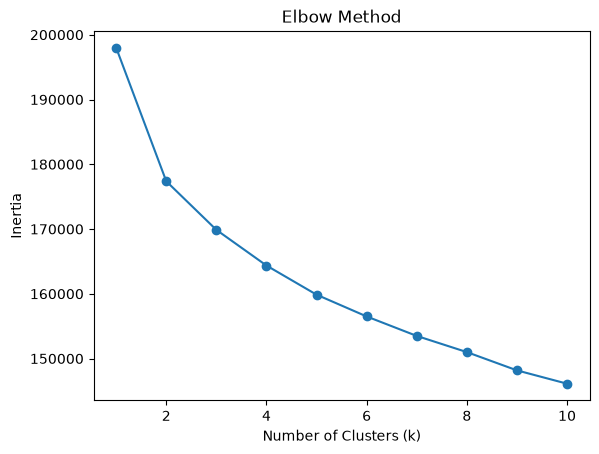

In [12]:
plt.plot(range(1,11),iners , marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

as we see here its 2 or maybe 3 we will se in **Silhouette Score**


## step 3- Compare Candidate k Values Using Silhouette Score

In [15]:
from sklearn.metrics import silhouette_score
for n in [2,3]:
    km=KMeans(n_clusters=n,random_state=42,n_init=10)
    label=km.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,label)
    print(f"k={n}, Silhouette Score={score}")

k=2, Silhouette Score=0.09581311069520027
k=3, Silhouette Score=0.06319235709294713


2 is the best

## Step 4- Fit final K-Means with the chosen k

the best kmeans 

In [21]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

add to dataset

In [22]:
df["cluster"] = cluster_labels

see the result

In [23]:
df["cluster"].value_counts()

cluster
1    4631
0    4369
Name: count, dtype: int64

 visualize the cluster with 2 fetures 

 age and daily steps

C:\Users\Hp\AppData\Local\Temp\ipykernel_17908\1282485356.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


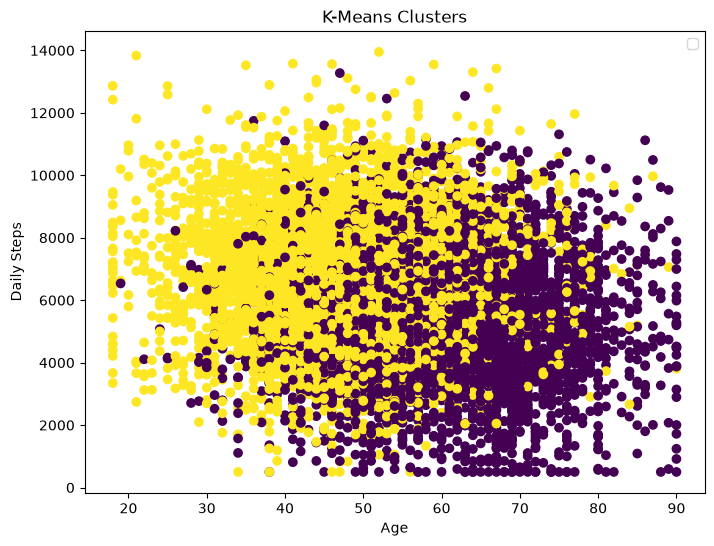

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["age"] ,
    df["daily_steps"],
    c=df["cluster"]
)

plt.xlabel("Age")
plt.ylabel("Daily Steps")
plt.title("K-Means Clusters")
plt.show()

## step 5- Cluster Interpretation

The K-Means model divided the patients into two clusters:

- **Cluster 0:** This cluster appears to contain more older patients, with many patients showing lower to moderate daily activity levels.

- **Cluster 1:** This cluster appears to contain more younger and middle-aged patients, with generally higher daily activity levels.

There is noticeable overlap between the two clusters, meaning that Age and Daily Steps alone do not completely explain the clustering.

The K-Means model was trained using all selected numerical features, while this visualization only shows the clusters using Age and Daily Steps.